# EMiF Project — Risk Structure After COVID-19

## Research question

Can we say that, since COVID-19, the structure of risk in financial markets has changed?

This notebook reproduces the empirical analysis used in the report. The analysis uses only the dataset provided in `Data.xlsx`.

We define the "structure of risk" as four dimensions:

1. Risk levels: volatility, tail risk, skewness and kurtosis.
2. Risk co-movement: correlations and asset-class block correlations.
3. Risk factors: principal component analysis and factor concentration.
4. Risk regimes: pre-COVID vs post-COVID comparisons and rolling indicators.

The main empirical split uses 11 March 2020 as the COVID breakpoint.

In [40]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make sure the notebook can import files from src/
PROJECT_ROOT = Path("..").resolve()
SRC_PATH = PROJECT_ROOT / "src"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Source path:", SRC_PATH)

Project root: C:\Users\Pc\Downloads\Emif-Project-2
Source path: C:\Users\Pc\Downloads\Emif-Project-2\src


In [41]:
from src.data_loader import load_raw_data
from src.transformations import prepare_returns, split_pre_post_covid
from src.risk_metrics import compare_pre_post_risk
from src.correlation_analysis import (
    compare_pre_post_correlations,
    summarize_correlation_change,
    summarize_block_correlations,
)
from src.pca_analysis import compare_pre_post_pca
from src.rolling_analysis import (
    compute_rolling_volatility,
    compute_rolling_average_correlation,
)
from src.plots import (
    plot_volatility_change,
    plot_block_correlation_change,
    plot_correlation_difference_heatmap,
    plot_pca_explained_variance,
    plot_rolling_volatility,
    plot_rolling_average_correlation,
)

print("All project modules imported successfully.")

All project modules imported successfully.


In [42]:
DATA_PATH = PROJECT_ROOT / "data" / "Data.xlsx"
TABLE_DIR = PROJECT_ROOT / "results" / "tables"
FIGURE_DIR = PROJECT_ROOT / "results" / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Data path:", DATA_PATH)
print("Tables will be saved in:", TABLE_DIR)
print("Figures will be saved in:", FIGURE_DIR)

Data path: C:\Users\Pc\Downloads\Emif-Project-2\data\Data.xlsx
Tables will be saved in: C:\Users\Pc\Downloads\Emif-Project-2\results\tables
Figures will be saved in: C:\Users\Pc\Downloads\Emif-Project-2\results\figures


## 1. Data loading

The raw dataset is loaded from `Data.xlsx`. The first step is to inspect the available variables, the date range and missing values.

In [43]:
raw_df = load_raw_data(DATA_PATH)

print("Raw data shape:", raw_df.shape)
print("Start date:", raw_df.index.min())
print("End date:", raw_df.index.max())

raw_df.head()

Raw data shape: (9601, 14)
Start date: 1989-12-31 00:00:00
End date: 2026-04-24 00:00:00


,S&P500,Eurostoxx 50,Hang Seng,MSCI EM,SMI,US T 10-year Yield,German Gov 10-year yield,Oil futures,Gold,EURUSD,USDJPY,US IG Bonds,US HY Bonds,USDCHF
Unnamed: 0,,,,,,,,,,,,,,
1989-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,447.981,182.305,NaN
1990-01-01,NaN,1098.4900,NaN,214.69,NaN,NaN,NaN,NaN,NaN,NaN,143.80,NaN,NaN,1.5410
1990-01-02,359.69,1101.3400,2838.0701,217.30,NaN,7.930,7.484,22.89,399.0,1.2146,146.25,447.921,182.472,1.5768
1990-01-03,358.76,1112.8199,2858.7200,220.45,1824.0,7.974,7.507,23.68,395.0,1.2096,145.70,447.405,182.591,1.5785
1990-01-04,355.67,1113.0200,2867.9500,227.30,1824.5,7.972,7.428,23.41,396.5,1.2287,143.37,447.325,182.935,1.5420


In [44]:
missing_values = raw_df.isna().sum().sort_values(ascending=False)
missing_values

Oil futures                 679
Hang Seng                   640
US T 10-year Yield          524
SMI                         475
S&P500                      456
German Gov 10-year yield    392
Eurostoxx 50                256
EURUSD                      198
Gold                        185
US HY Bonds                 155
US IG Bonds                 142
MSCI EM                     126
USDJPY                      126
USDCHF                      126
dtype: int64

## 2. Return transformations and sample split

Following the EMiF course, prices and indices are transformed into returns because financial returns are more suitable for empirical analysis than price levels. Most price-like series are transformed into log returns. Government bond yields are transformed into daily changes in basis points.

Oil futures require special treatment because WTI futures became negative in April 2020. Therefore, the oil series is transformed using the inverse hyperbolic sine difference, which is defined for negative values.

In [45]:
returns_df = prepare_returns(raw_df)

print("Returns data shape:", returns_df.shape)
print("Start date:", returns_df.index.min())
print("End date:", returns_df.index.max())

returns_df.head()

Returns data shape: (7332, 14)
Start date: 1990-01-04 00:00:00
End date: 2026-04-24 00:00:00


,S&P500,Eurostoxx 50,Hang Seng,MSCI EM,SMI,US T 10-year Yield,German Gov 10-year yield,Oil futures,Gold,EURUSD,USDJPY,US IG Bonds,US HY Bonds,USDCHF
Date,,,,,,,,,,,,,,
1990-01-04,-0.008650,0.000180,0.003224,0.030600,0.000274,-0.2,-7.9,-0.011457,0.003790,0.015667,-0.016121,-0.000179,0.001882,-0.023395
1990-01-05,-0.009804,-0.012203,-0.009815,0.007058,-0.012520,1.2,7.4,-0.014184,0.021211,0.005762,0.003134,0.000118,0.001480,-0.003248
1990-01-08,0.004504,0.004628,-0.008380,-0.008864,-0.000833,2.8,0.5,-0.065282,-0.000988,0.007578,0.001945,-0.000143,0.000955,-0.008625
1990-01-09,-0.011857,0.003768,0.002100,0.008033,0.003604,-0.3,-0.5,0.020579,-0.002846,-0.007739,0.007605,0.000034,0.000578,0.002098
1990-01-10,-0.006629,-0.008068,0.016112,0.003709,-0.001385,0.5,-2.4,0.036881,0.013907,0.000405,0.000344,-0.000250,0.000365,-0.009541


In [46]:
pre_covid, post_covid = split_pre_post_covid(
    returns_df,
    breakpoint="2020-03-11",
)

print("Pre-COVID shape:", pre_covid.shape)
print("Pre-COVID period:", pre_covid.index.min(), "to", pre_covid.index.max())

print("Post-COVID shape:", post_covid.shape)
print("Post-COVID period:", post_covid.index.min(), "to", post_covid.index.max())

Pre-COVID shape: (6064, 14)
Pre-COVID period: 1990-01-04 00:00:00 to 2020-03-10 00:00:00
Post-COVID shape: (1268, 14)
Post-COVID period: 2020-03-11 00:00:00 to 2026-04-24 00:00:00


## 3. Risk levels: pre-COVID vs post-COVID

This section compares the level and distribution of risk before and after COVID-19.

We compute the following metrics for each asset:

- Annualized volatility
- Skewness
- Excess kurtosis
- Historical 5% Value-at-Risk
- Historical 5% Conditional Value-at-Risk

These indicators are linked to the EMiF course discussion of financial return moments, non-normality, fat tails and volatility. They allow us to test whether the level and shape of asset risk changed after COVID-19.

In [47]:
risk_comparison = compare_pre_post_risk(pre_covid, post_covid)

risk_comparison_rounded = risk_comparison.round(4)
risk_comparison_rounded

,Vol_ann_pre,Vol_ann_post,Vol_change,Vol_change_%,Skew_pre,Skew_post,Excess_Kurtosis_pre,Excess_Kurtosis_post,VaR_5_pre,VaR_5_post,CVaR_5_pre,CVaR_5_post
Asset,,,,,,,,,,,,
S&P500,0.1735,0.2067,0.0332,0.1914,-0.3870,-0.5226,7.8723,16.8564,-0.0172,-0.0175,-0.0267,-0.0304
Eurostoxx 50,0.2077,0.1989,-0.0088,-0.0424,-0.2508,-0.7270,4.9161,14.3781,-0.0211,-0.0172,-0.0318,-0.0292
Hang Seng,0.2442,0.2365,-0.0078,-0.0318,-0.0599,0.0952,10.2691,3.1240,-0.0237,-0.0219,-0.0365,-0.0309
MSCI EM,0.1796,0.1755,-0.0041,-0.0227,-0.5314,-0.4364,7.8412,4.5872,-0.0181,-0.0165,-0.0277,-0.0256
SMI,0.1743,0.1496,-0.0247,-0.1418,-0.4761,-0.7876,5.6934,14.8558,-0.0171,-0.0134,-0.0270,-0.0216
US T 10-year Yield,92.5748,96.2001,3.6253,0.0392,0.0330,-0.1711,2.0921,2.3154,-9.2970,-9.5320,-12.7267,-13.5702
German Gov 10-year yield,69.2791,81.9287,12.6496,0.1826,0.2047,-0.2935,2.4918,3.3579,-6.6470,-7.8615,-9.3987,-12.2206
Oil futures,0.3771,4.8371,4.4600,11.8266,-1.1126,-2.9294,20.5894,620.7270,-0.0359,-0.0404,-0.0550,-0.1946
Gold,0.1557,0.1793,0.0236,0.1518,-0.2601,-0.7031,8.6104,6.5363,-0.0149,-0.0175,-0.0235,-0.0272


In [48]:
risk_table_path = TABLE_DIR / "risk_comparison_pre_post.csv"
risk_comparison.to_csv(risk_table_path)

print("Risk comparison table saved to:", risk_table_path)

Risk comparison table saved to: C:\Users\Pc\Downloads\Emif-Project-2\results\tables\risk_comparison_pre_post.csv


In [49]:
vol_changes = risk_comparison["Vol_change"].sort_values(ascending=False)

print("Largest increases in annualized risk:")
display(vol_changes.head(7).round(4))

print("Largest decreases in annualized risk:")
display(vol_changes.tail(7).round(4))

Largest increases in annualized risk:


Asset
German Gov 10-year yield    12.6496
Oil futures                  4.4600
US T 10-year Yield           3.6253
S&P500                       0.0332
Gold                         0.0236
US HY Bonds                  0.0218
US IG Bonds                  0.0185
Name: Vol_change, dtype: float64

Largest decreases in annualized risk:


Asset
MSCI EM        -0.0041
Hang Seng      -0.0078
Eurostoxx 50   -0.0088
USDJPY         -0.0098
EURUSD         -0.0205
SMI            -0.0247
USDCHF         -0.0331
Name: Vol_change, dtype: float64

### Figure: change in annualized volatility

The following figure shows the difference between post-COVID and pre-COVID annualized volatility. Positive values mean that realized risk increased after COVID-19.

In [50]:
plot_volatility_change(
    risk_comparison,
    output_path=FIGURE_DIR / "volatility_change_pre_post.png",
)

img_path = FIGURE_DIR / "volatility_change_pre_post.png"
print("Figure saved to:", img_path)

Figure saved to: C:\Users\Pc\Downloads\Emif-Project-2\results\figures\volatility_change_pre_post.png


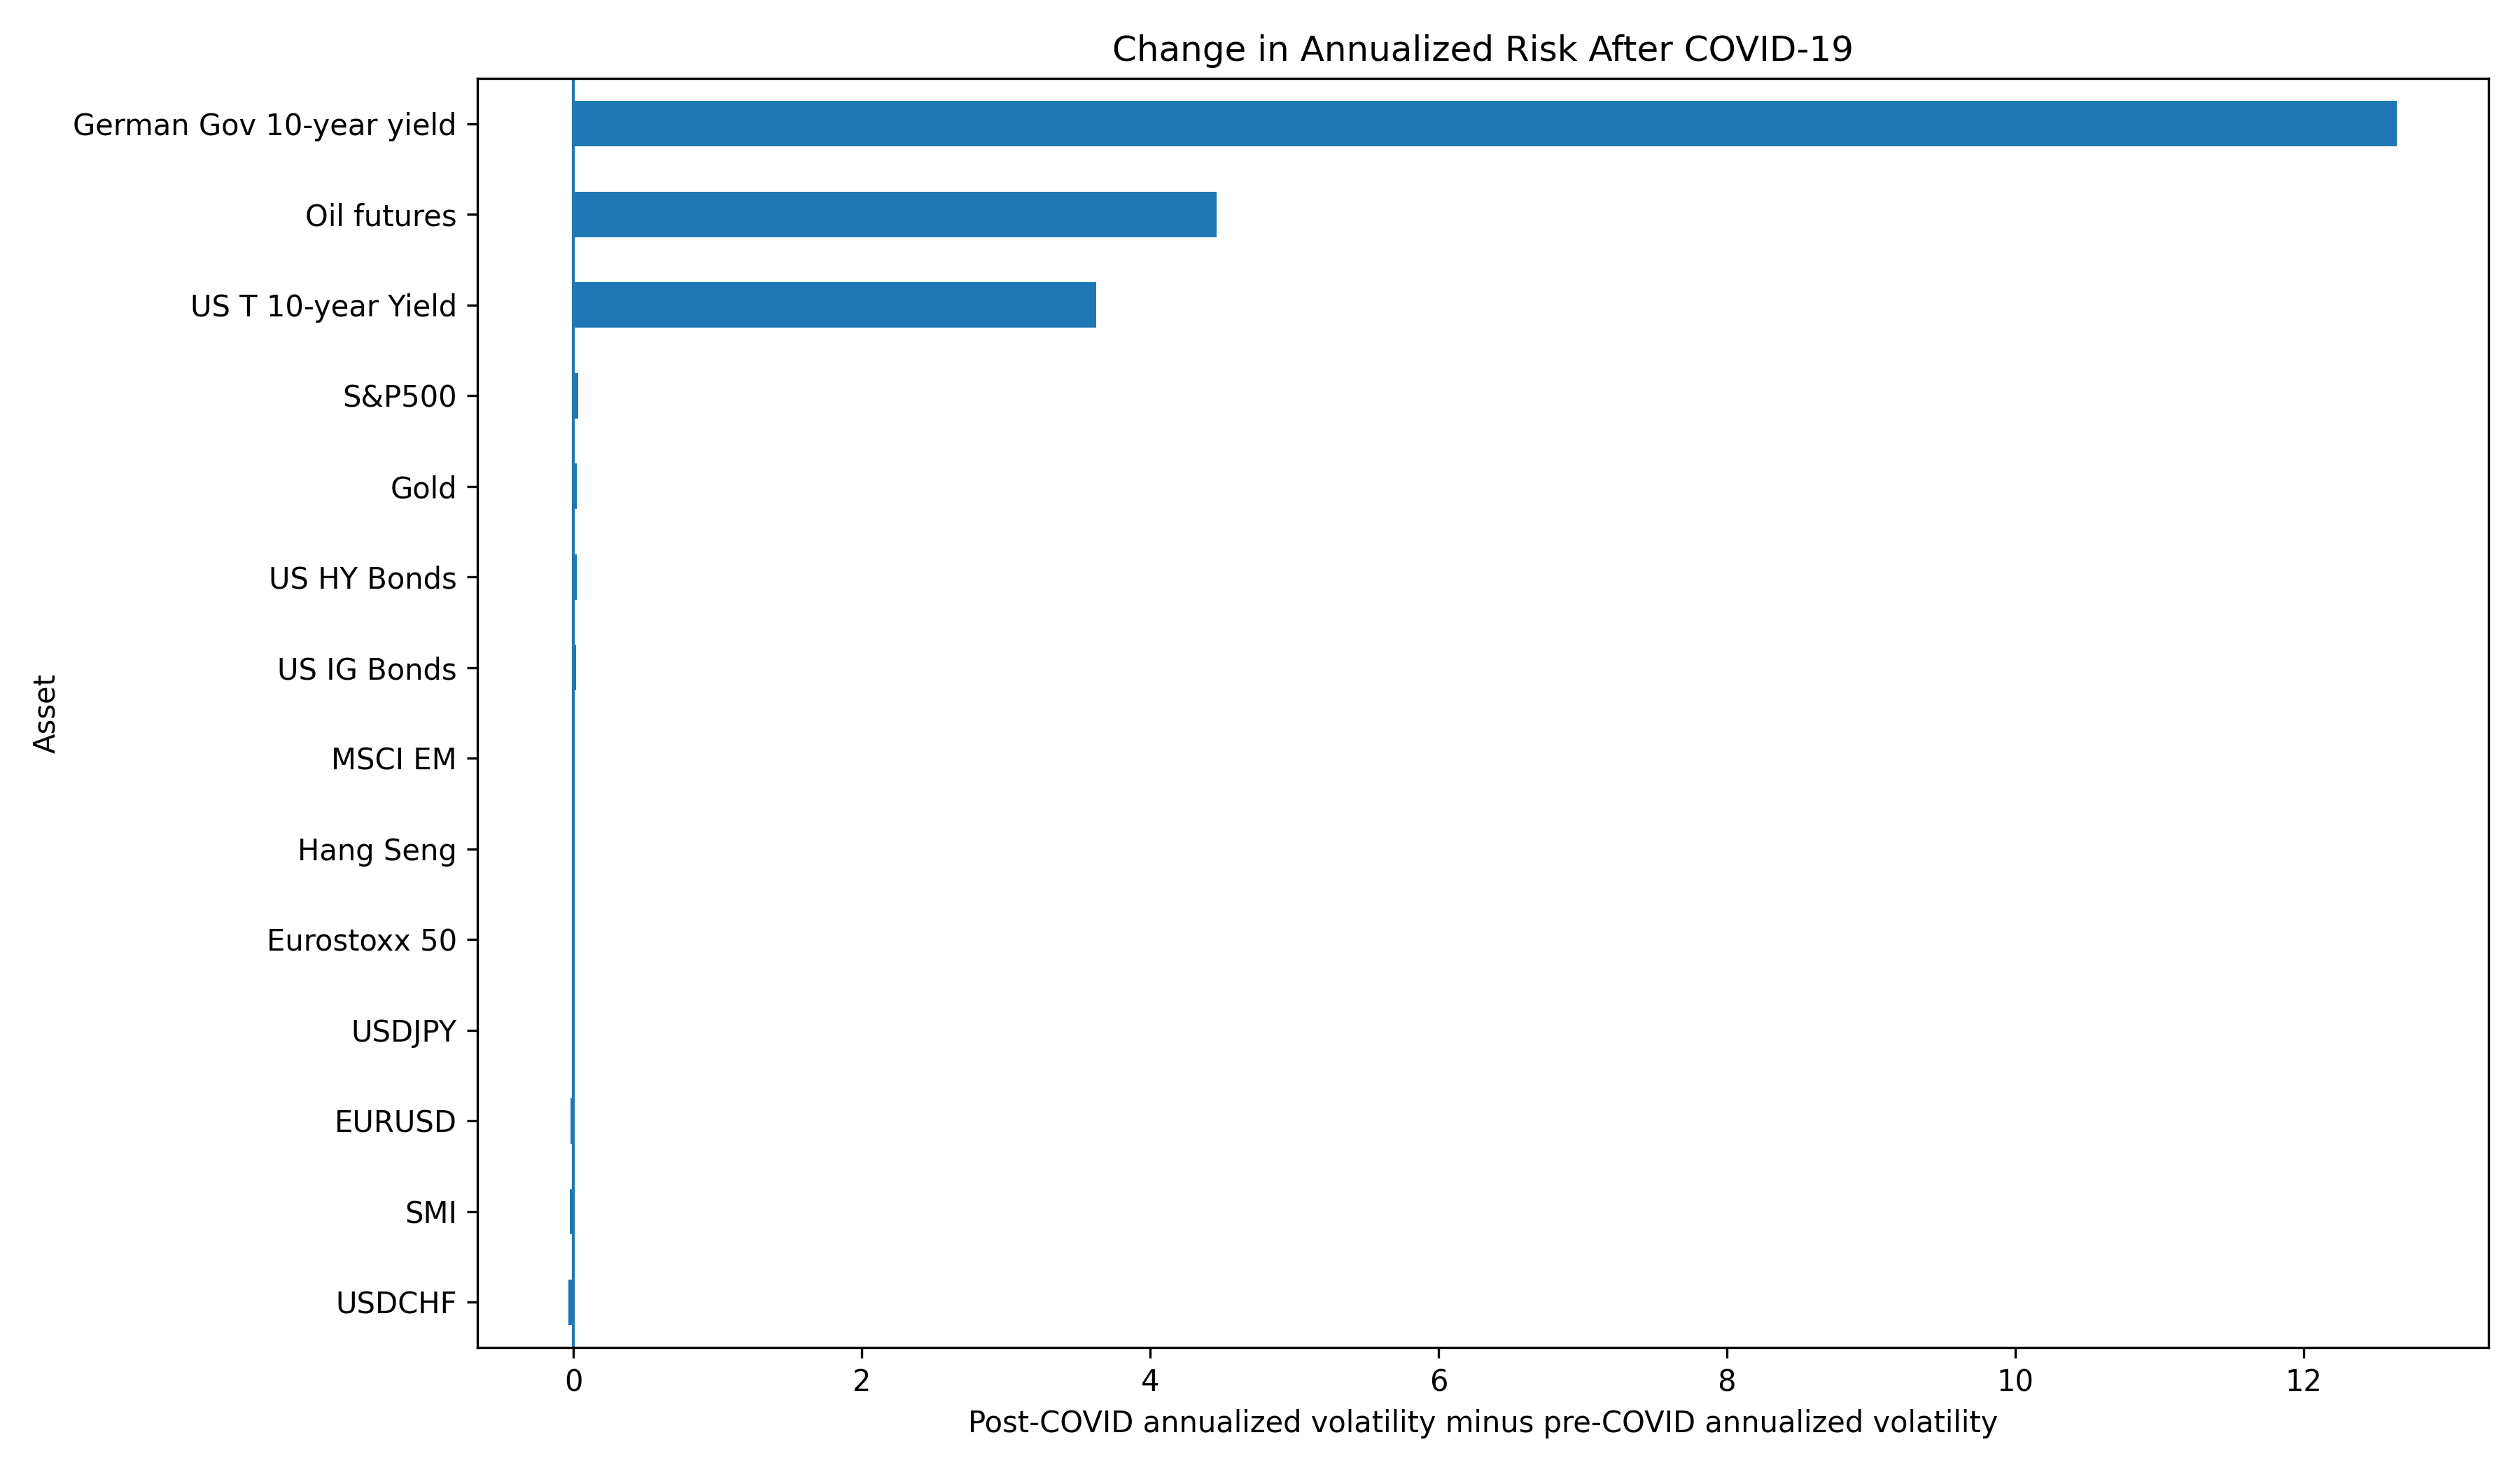

In [51]:
from IPython.display import Image, display

display(Image(filename=str(img_path)))

### Interpretation

The volatility results suggest that the post-COVID change in risk levels was not uniform across asset classes.

Risk increased particularly for oil futures, government yield changes, credit bonds, gold and the S&P500. This indicates that COVID-19 did not only affect equity risk, but also energy risk, rates risk and credit risk.

However, several assets show lower or broadly stable annualized volatility after COVID-19, including some equity indices and FX rates. Therefore, the evidence does not support the idea that all markets simply became riskier after COVID-19.

The first conclusion is therefore partial: risk levels changed after COVID-19, but the change was selective across asset classes.

## 4. Risk co-movement: correlations and diversification

This section studies whether cross-asset co-movements changed after COVID-19.

Correlation analysis helps answer whether diversification benefits changed. If correlations rise after COVID, assets move more together and diversification becomes less effective. If correlations fall or change selectively, the structure of risk changes in a more nuanced way.

We compute:

1. Pre-COVID correlation matrix.
2. Post-COVID correlation matrix.
3. Difference matrix: post-COVID minus pre-COVID.
4. Average pairwise correlation.
5. Asset-class block correlations.

In [52]:
corr_pre, corr_post, corr_diff = compare_pre_post_correlations(
    pre_covid,
    post_covid,
)

corr_summary = summarize_correlation_change(corr_pre, corr_post)
block_corr_summary = summarize_block_correlations(corr_pre, corr_post)

print("Average correlation summary:")
display(corr_summary.round(4))

print("Block correlation summary:")
display(block_corr_summary.round(4))

Average correlation summary:


,Average_correlation_pre,Average_correlation_post,Change
0,0.1022,0.0842,-0.018


Block correlation summary:


,Correlation_pre,Correlation_post,Change
Block,,,
Equities within,0.4783,0.4550,-0.0233
Yields within,0.5024,0.6553,0.1530
Commodities within,0.1839,-0.0103,-0.1942
FX within,-0.2063,-0.2314,-0.0251
Credit within,0.2503,0.5566,0.3063
Equities vs Yields,0.1620,0.0346,-0.1274
Equities vs Credit,0.1375,0.3142,0.1767
Equities vs Commodities,0.0641,0.0440,-0.0201
Equities vs FX,0.0819,0.0328,-0.0491


In [53]:
corr_pre.to_csv(TABLE_DIR / "correlation_matrix_pre_covid.csv")
corr_post.to_csv(TABLE_DIR / "correlation_matrix_post_covid.csv")
corr_diff.to_csv(TABLE_DIR / "correlation_matrix_difference.csv")
corr_summary.to_csv(TABLE_DIR / "correlation_summary.csv", index=False)
block_corr_summary.to_csv(TABLE_DIR / "block_correlation_summary.csv")

print("Correlation tables saved.")

Correlation tables saved.


In [54]:
block_changes = block_corr_summary["Change"].sort_values(ascending=False)

print("Largest increases in block correlations:")
display(block_changes.head(5).round(4))

print("Largest decreases in block correlations:")
display(block_changes.tail(5).round(4))

Largest increases in block correlations:


Block
Credit within              0.3063
Equities vs Credit         0.1767
Yields within              0.1530
Equities vs Commodities   -0.0201
Equities within           -0.0233
Name: Change, dtype: float64

Largest decreases in block correlations:


Block
FX within            -0.0251
Equities vs FX       -0.0491
Credit vs Yields     -0.1246
Equities vs Yields   -0.1274
Commodities within   -0.1942
Name: Change, dtype: float64

### Figures: correlation changes

The first figure shows changes in asset-class block correlations. The second figure shows the full correlation difference matrix, where each cell is post-COVID correlation minus pre-COVID correlation.

In [55]:
plot_block_correlation_change(
    block_corr_summary,
    output_path=FIGURE_DIR / "block_correlation_change.png",
)

plot_correlation_difference_heatmap(
    corr_diff,
    output_path=FIGURE_DIR / "correlation_difference_heatmap.png",
)

print("Correlation figures saved.")

Correlation figures saved.


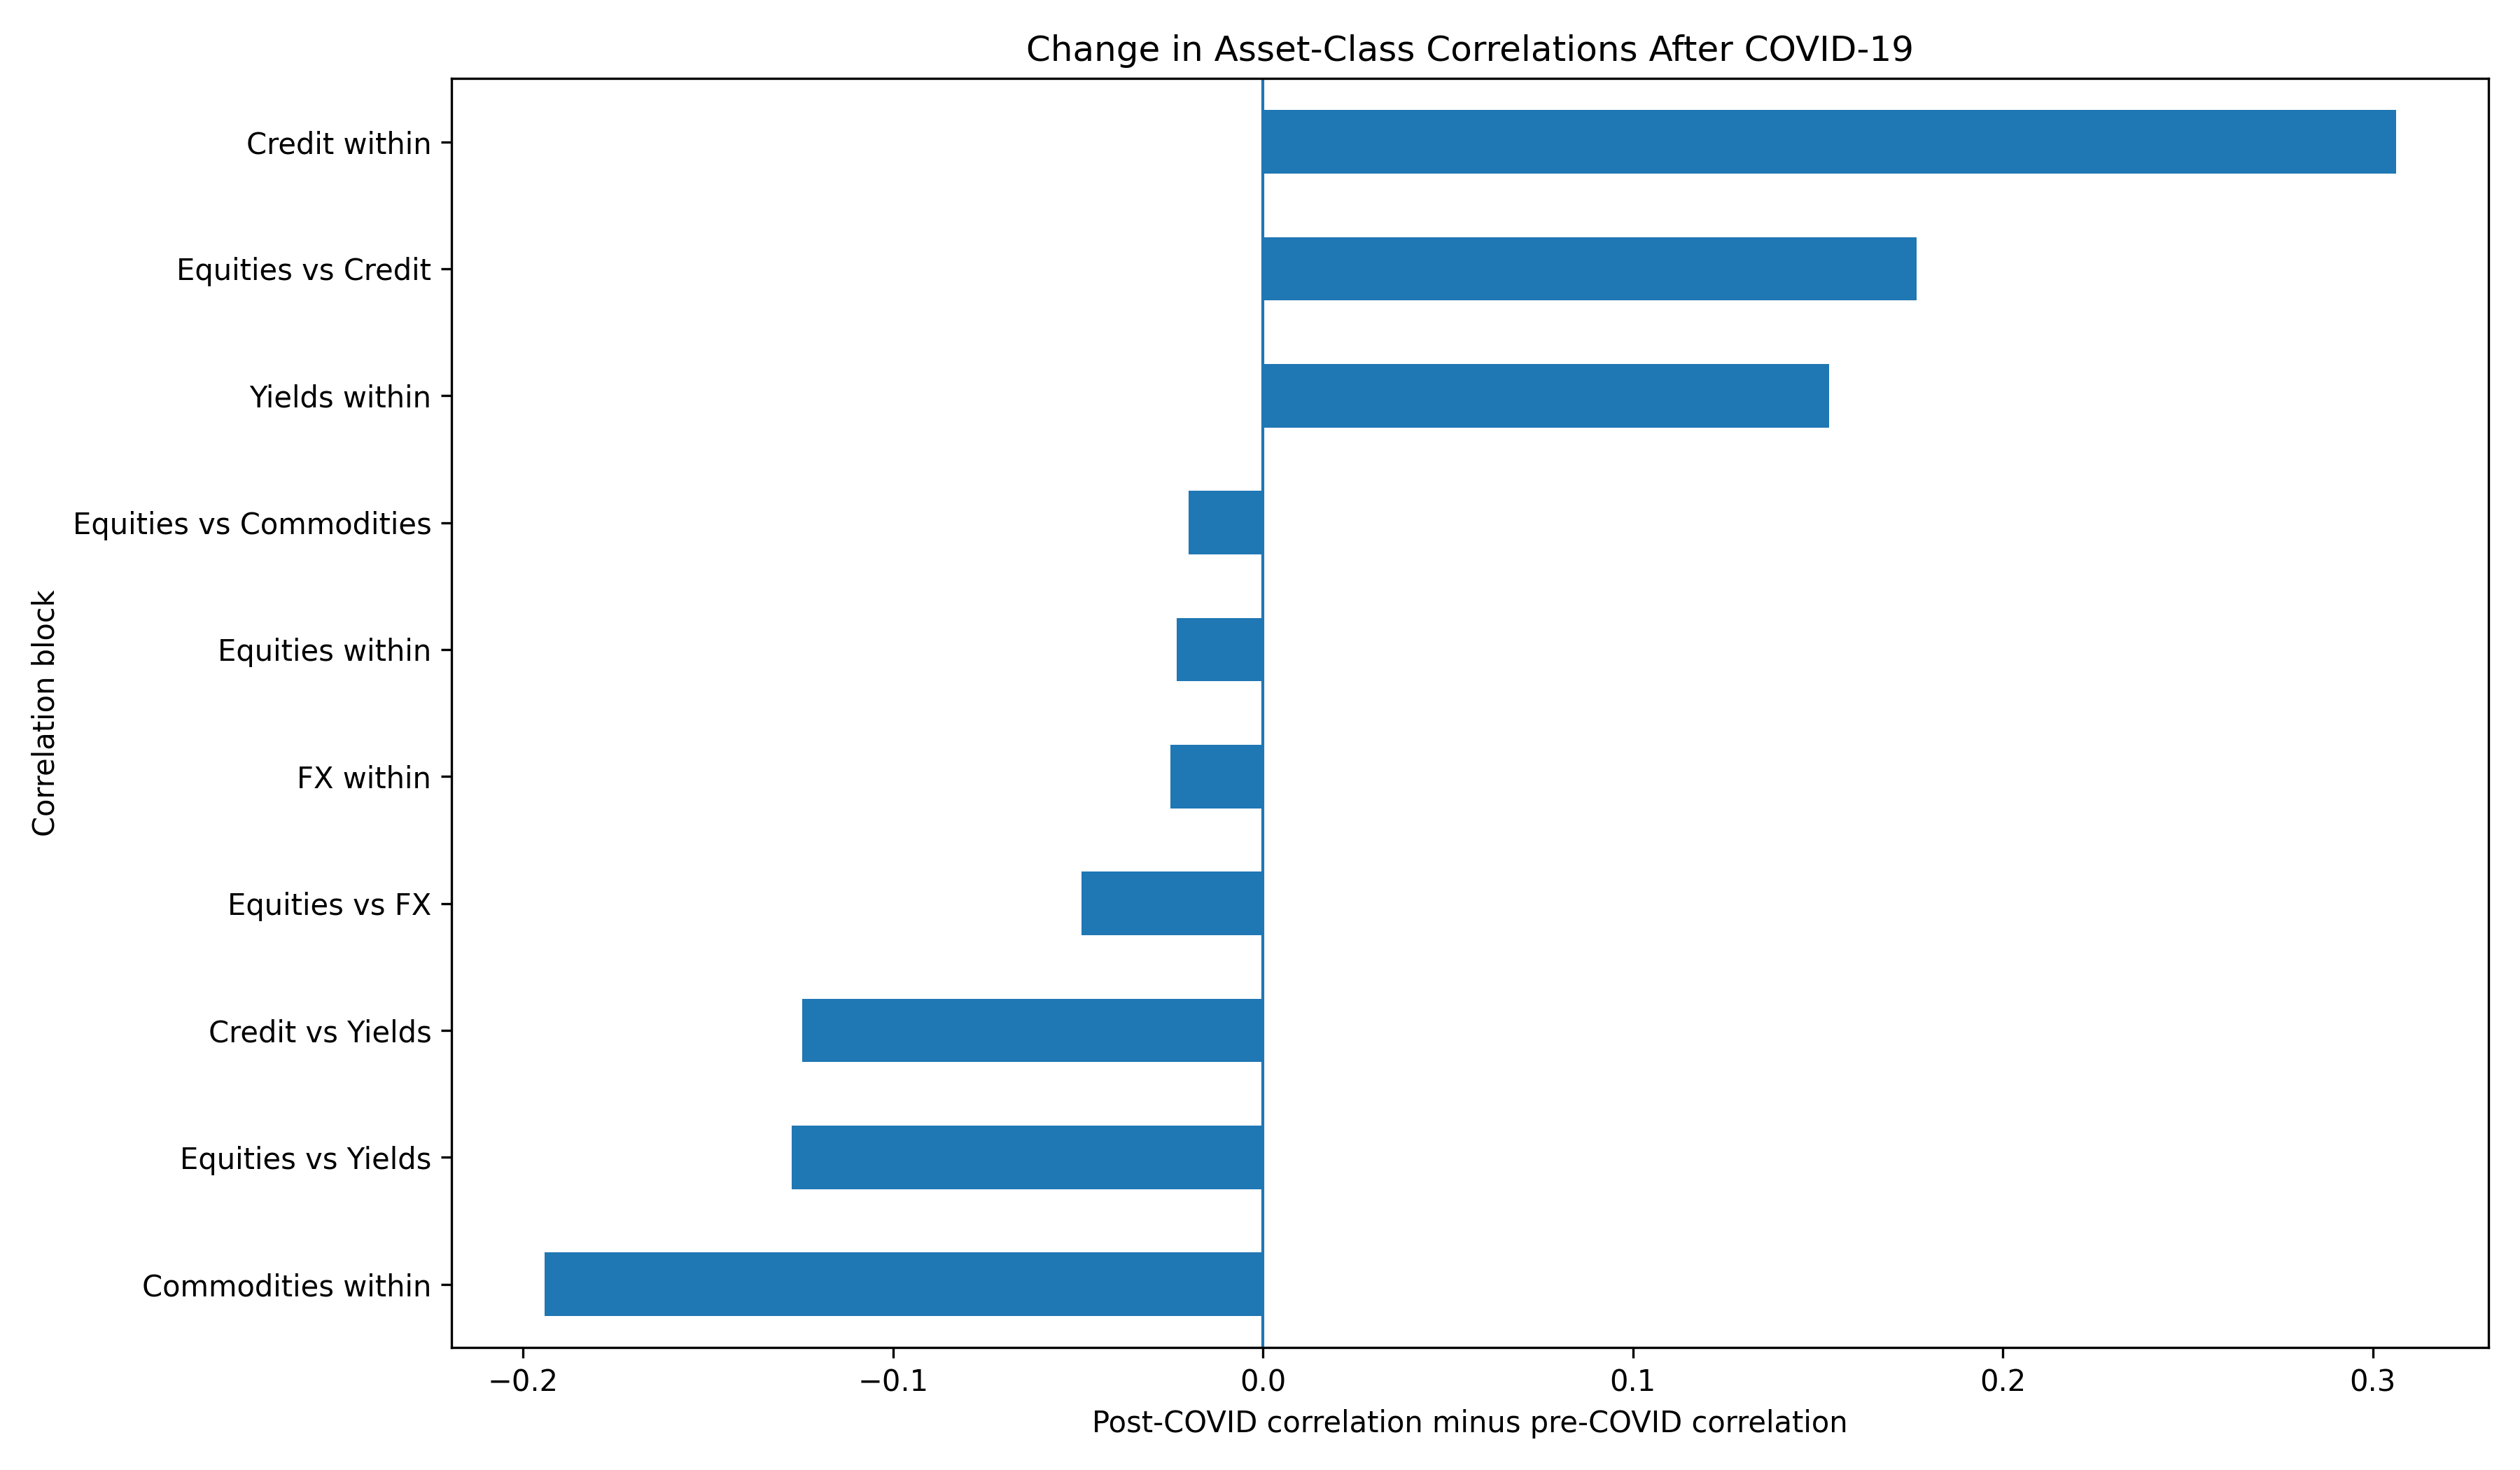

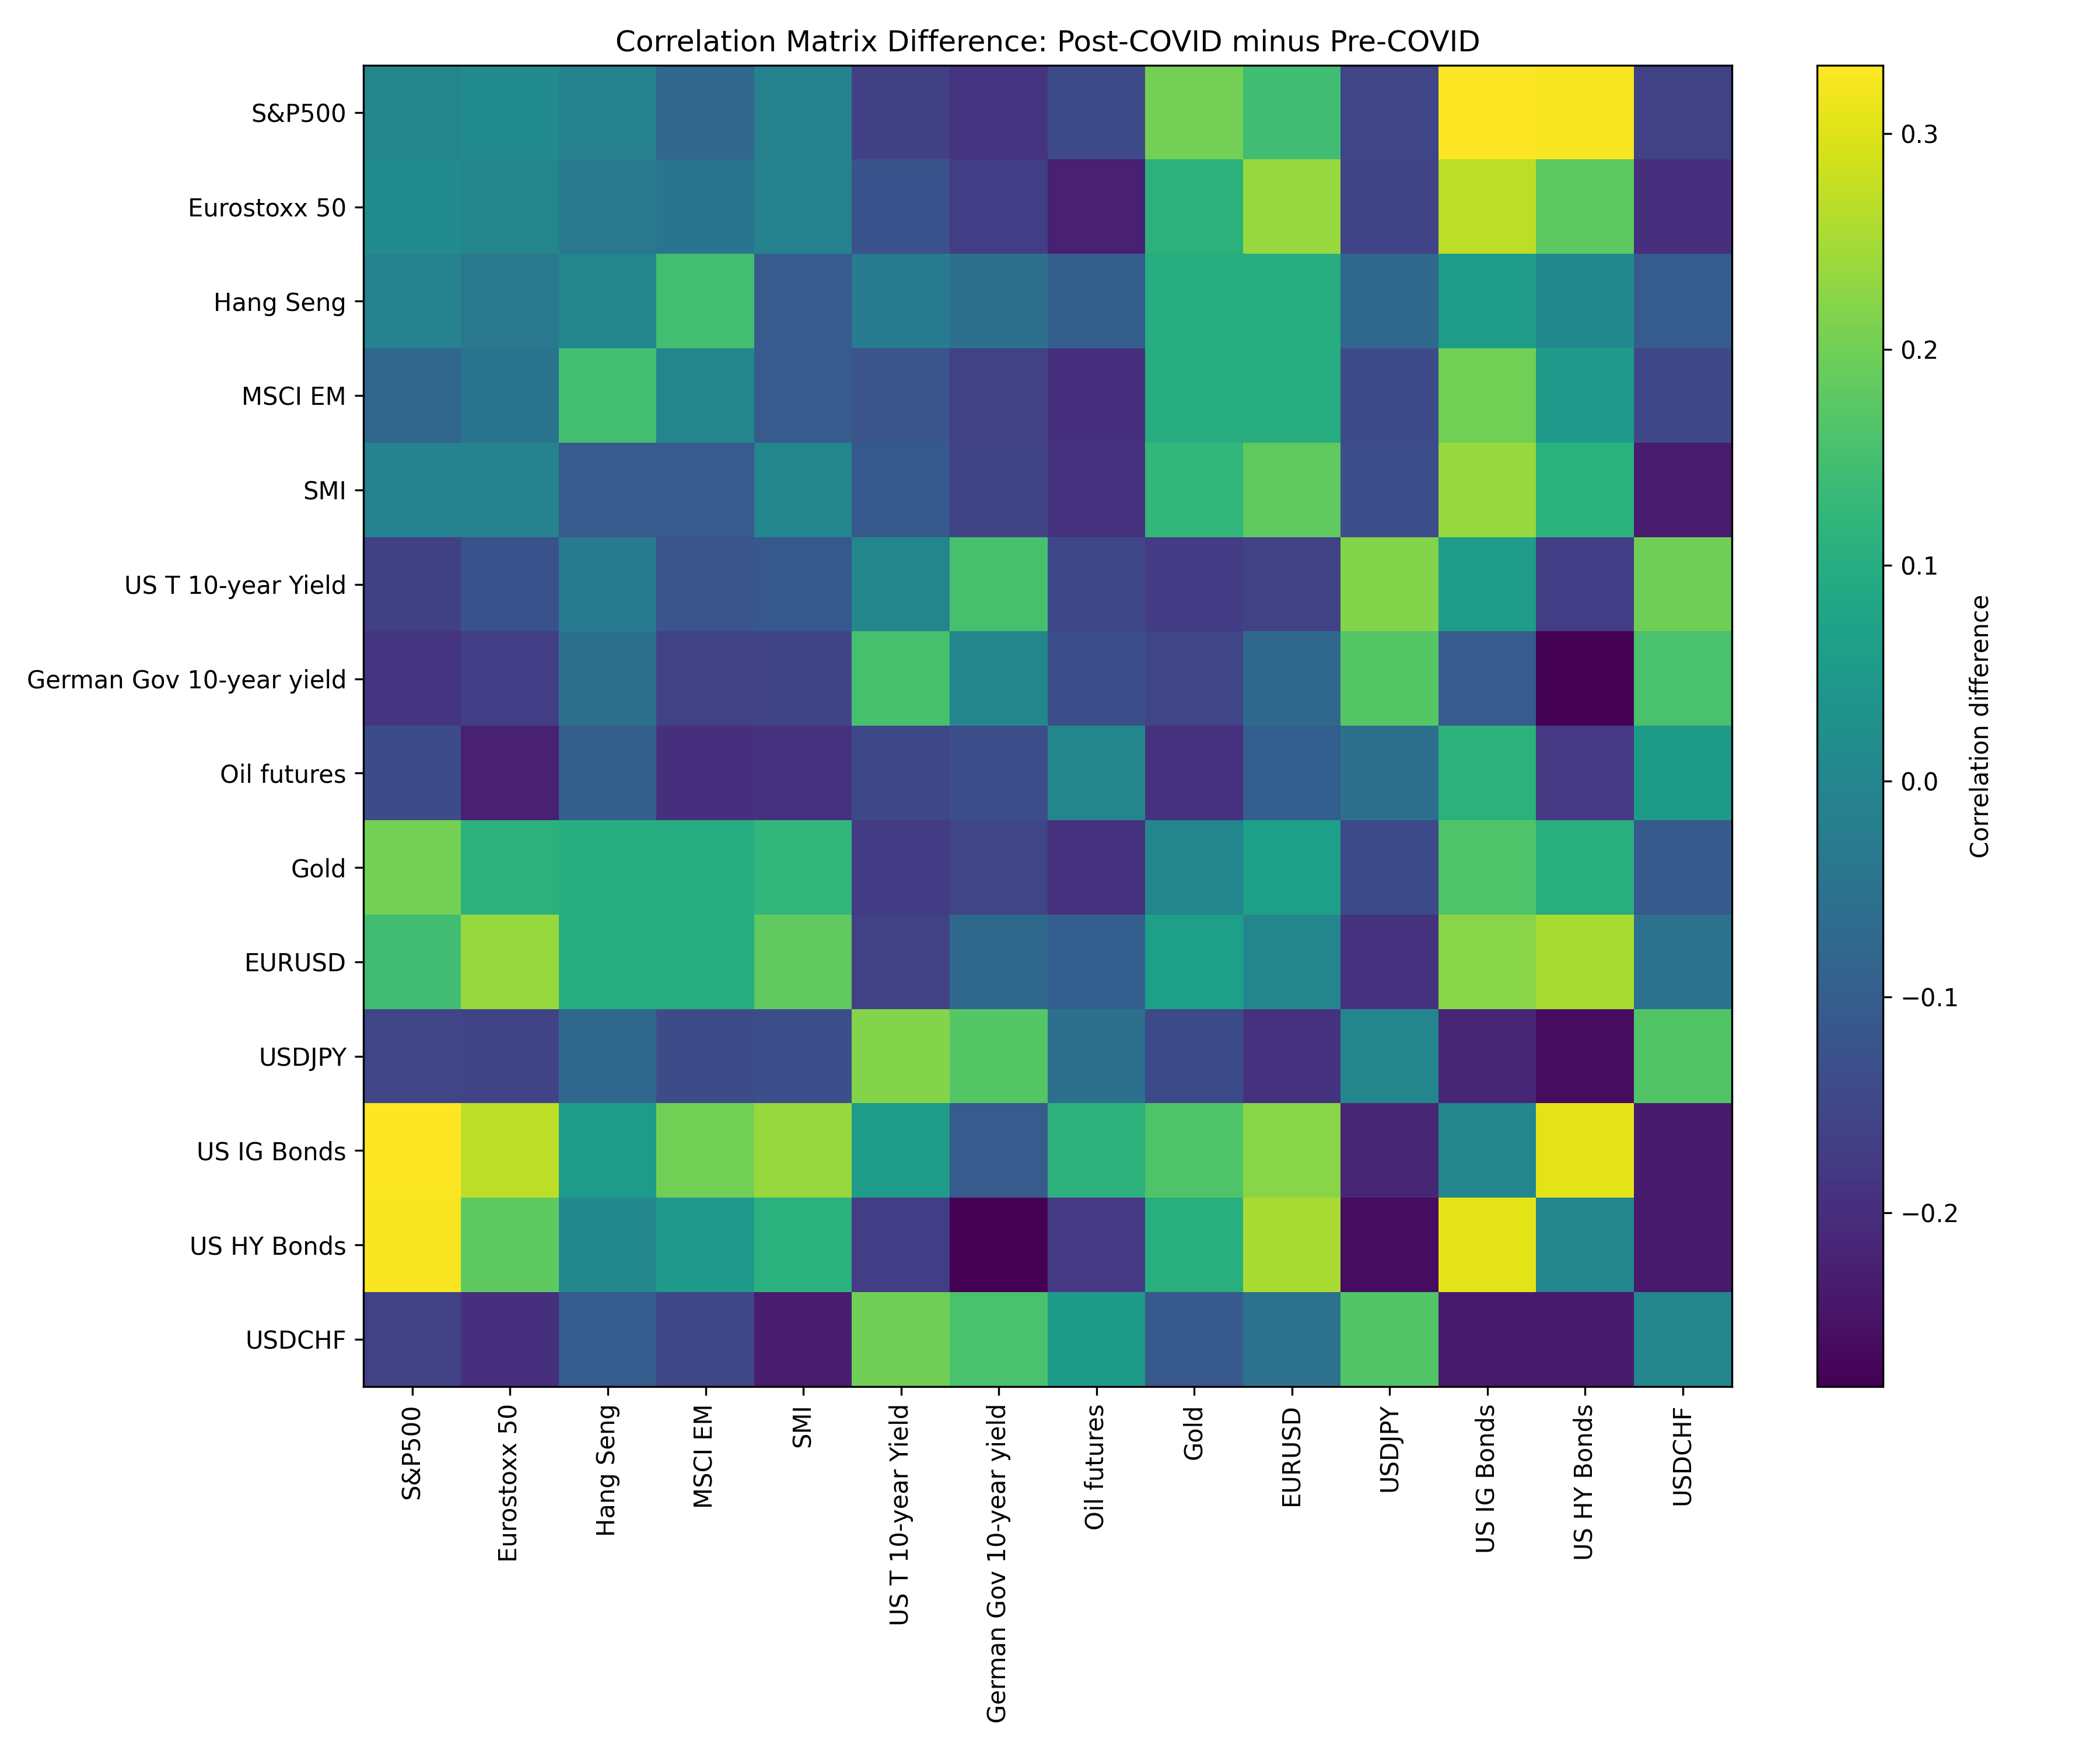

In [56]:
block_corr_img = FIGURE_DIR / "block_correlation_change.png"
heatmap_img = FIGURE_DIR / "correlation_difference_heatmap.png"

display(Image(filename=str(block_corr_img)))
display(Image(filename=str(heatmap_img)))

### Interpretation

The correlation results do not show a generalized increase in cross-asset correlations after COVID-19. The average pairwise correlation slightly declined after COVID.

However, the block-level results show important changes in the internal structure of co-movements. Credit markets became much more internally correlated, and the correlation between equities and credit increased strongly. This suggests that credit risk became more closely connected to broader risk-asset dynamics after COVID.

Government yield changes also became more synchronized, suggesting a stronger global rates or inflation channel. At the same time, equity-yield correlations declined, and commodity co-movement weakened.

Therefore, COVID-19 did not simply make all assets move together. Instead, it changed the correlation structure selectively, especially through credit and rates channels. This is important for portfolio management because diversification benefits changed across asset classes.

## 5. Risk factors: Principal Component Analysis

This section studies whether financial market risk became more concentrated in a smaller number of common factors after COVID-19.

Principal Component Analysis (PCA) transforms the cross-section of asset returns into orthogonal components. If the first principal components explain more variance after COVID, it means that a larger share of market risk is driven by common shocks.

To avoid high-volatility assets mechanically dominating the PCA, the analysis is performed on standardized returns.

In [57]:
explained_pre, explained_post, pca_comparison, loadings_pre, loadings_post = (
    compare_pre_post_pca(pre_covid, post_covid)
)

print("PCA explained variance comparison:")
display(pca_comparison.head(10).round(4))

PCA explained variance comparison:


,Explained_pre,Explained_post,Change
PC1,0.2581,0.2946,0.0365
PC2,0.1764,0.2086,0.0322
PC3,0.1387,0.1123,-0.0264
PC4,0.0728,0.0863,0.0135
PC5,0.0682,0.0720,0.0038
PC6,0.0561,0.0537,-0.0023
PC7,0.0503,0.0468,-0.0035
PC8,0.0475,0.0323,-0.0152
PC9,0.0395,0.0271,-0.0124
PC10,0.0350,0.0213,-0.0137


In [58]:
pc12_pre = pca_comparison.loc[["PC1", "PC2"], "Explained_pre"].sum()
pc12_post = pca_comparison.loc[["PC1", "PC2"], "Explained_post"].sum()
pc12_change = pc12_post - pc12_pre

print(f"PC1 + PC2 explained variance pre-COVID:  {pc12_pre:.4f}")
print(f"PC1 + PC2 explained variance post-COVID: {pc12_post:.4f}")
print(f"Change: {pc12_change:.4f}")

PC1 + PC2 explained variance pre-COVID:  0.4345
PC1 + PC2 explained variance post-COVID: 0.5032
Change: 0.0687


In [59]:
print("PC1 loadings pre-COVID:")
display(loadings_pre["PC1"].sort_values(ascending=False).round(4))

print("PC1 loadings post-COVID:")
display(loadings_post["PC1"].sort_values(ascending=False).round(4))

PC1 loadings pre-COVID:


US IG Bonds                 0.2004
EURUSD                      0.0539
Gold                        0.0526
USDCHF                     -0.1354
Oil futures                -0.1401
USDJPY                     -0.2062
German Gov 10-year yield   -0.2304
US HY Bonds                -0.2493
US T 10-year Yield         -0.2685
Hang Seng                  -0.2768
S&P500                     -0.3408
MSCI EM                    -0.3780
SMI                        -0.4043
Eurostoxx 50               -0.4328
Name: PC1, dtype: float64

PC1 loadings post-COVID:


USDCHF                      0.3037
USDJPY                      0.2500
US T 10-year Yield          0.2483
German Gov 10-year yield    0.2041
Oil futures                 0.0219
Hang Seng                  -0.2074
Gold                       -0.2432
SMI                        -0.2446
S&P500                     -0.2458
Eurostoxx 50               -0.2790
MSCI EM                    -0.2918
EURUSD                     -0.3094
US IG Bonds                -0.3509
US HY Bonds                -0.3705
Name: PC1, dtype: float64

In [60]:
explained_pre.to_csv(TABLE_DIR / "pca_explained_variance_pre.csv")
explained_post.to_csv(TABLE_DIR / "pca_explained_variance_post.csv")
pca_comparison.to_csv(TABLE_DIR / "pca_explained_variance_comparison.csv")
loadings_pre.to_csv(TABLE_DIR / "pca_loadings_pre.csv")
loadings_post.to_csv(TABLE_DIR / "pca_loadings_post.csv")

print("PCA tables saved.")

PCA tables saved.


### Figure: PCA explained variance

The following figure compares the variance explained by the first principal components before and after COVID-19.

In [61]:
plot_pca_explained_variance(
    pca_comparison,
    output_path=FIGURE_DIR / "pca_explained_variance_pre_post.png",
)

pca_img = FIGURE_DIR / "pca_explained_variance_pre_post.png"
print("PCA figure saved to:", pca_img)

PCA figure saved to: C:\Users\Pc\Downloads\Emif-Project-2\results\figures\pca_explained_variance_pre_post.png


<Figure size 1000x600 with 0 Axes>

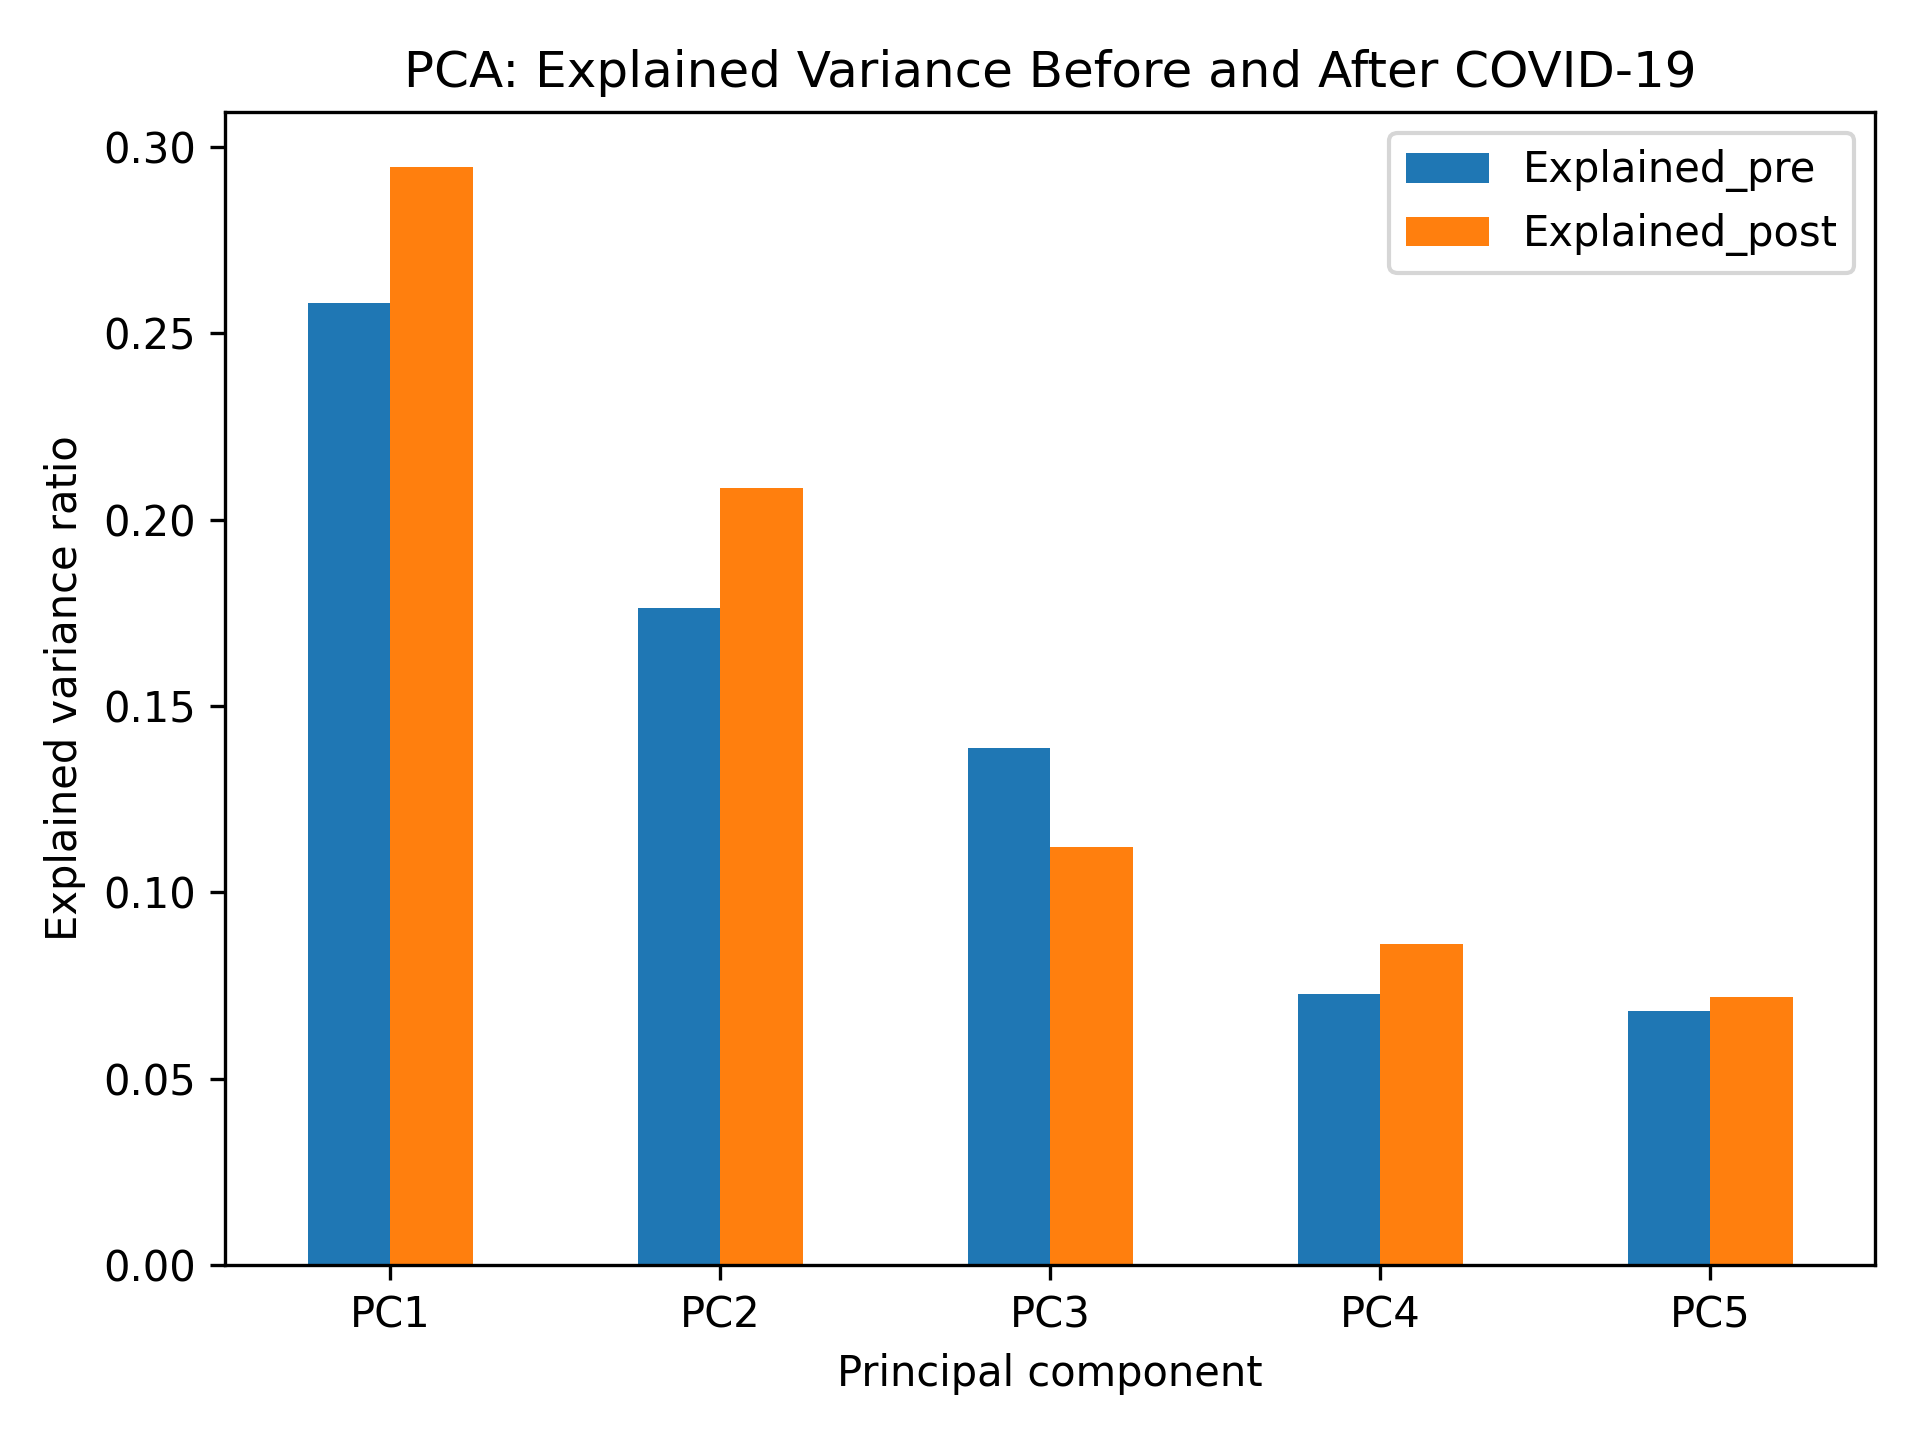

In [62]:
display(Image(filename=str(pca_img)))

### Interpretation

The PCA results show that risk became more concentrated after COVID-19.

The first principal component explains a larger share of total standardized variance after COVID. More importantly, the first two principal components together explain about 50% of total variance post-COVID, compared with about 43% before COVID.

This suggests that post-COVID market risk was more driven by common cross-asset factors. The loadings also indicate that the post-COVID first component is broader, involving equities, credit, FX, yields and gold. This supports the idea that risk shifted from a mainly equity-driven global risk factor toward a more integrated macro-financial risk factor.

This is one of the strongest pieces of evidence that the structure of risk changed after COVID-19.

## 6. Risk regimes: rolling volatility and rolling correlations

The previous sections compared pre-COVID and post-COVID averages. This section adds a dynamic view by computing rolling indicators.

We use a 252-day rolling window, which approximately corresponds to one trading year.

The objective is to observe whether COVID-19 coincides with a visible change in market risk regimes, especially in volatility and cross-asset correlation.

In [63]:
rolling_vol = compute_rolling_volatility(
    returns_df,
    window=252,
)

rolling_corr = compute_rolling_average_correlation(
    returns_df,
    window=252,
)

print("Rolling volatility shape:", rolling_vol.shape)
print("Rolling correlation length:", len(rolling_corr))

rolling_vol.tail()

Rolling volatility shape: (7332, 14)
Rolling correlation length: 7081


,S&P500,Eurostoxx 50,Hang Seng,MSCI EM,SMI,US T 10-year Yield,German Gov 10-year yield,Oil futures,Gold,EURUSD,USDJPY,US IG Bonds,US HY Bonds,USDCHF
Date,,,,,,,,,,,,,,
2026-04-20,0.174050,0.161346,0.199940,0.171371,0.135898,73.619483,62.628653,0.451892,0.247368,0.078124,0.095751,0.041365,0.030944,0.094021
2026-04-21,0.174100,0.161457,0.199156,0.171548,0.136193,73.653266,62.638675,0.452599,0.248353,0.078207,0.095593,0.041454,0.030988,0.094092
2026-04-22,0.174315,0.161512,0.199563,0.171666,0.136228,73.579236,62.615954,0.452488,0.248366,0.078303,0.095550,0.041393,0.030979,0.094241
2026-04-23,0.174345,0.161530,0.199147,0.171666,0.136880,73.596719,62.594064,0.453416,0.248560,0.077996,0.095562,0.041405,0.031001,0.094279
2026-04-24,0.173826,0.161420,0.199083,0.171698,0.136644,73.140745,62.490503,0.453205,0.248283,0.078041,0.095106,0.041143,0.031001,0.094215


In [64]:
rolling_corr.tail()

2026-04-20    0.054590
2026-04-21    0.054550
2026-04-22    0.054426
2026-04-23    0.053914
2026-04-24    0.053595
Name: Rolling_average_correlation, dtype: float64

In [65]:
rolling_vol.to_csv(TABLE_DIR / "rolling_volatility.csv")
rolling_corr.to_csv(TABLE_DIR / "rolling_average_correlation.csv")

print("Rolling analysis tables saved.")

Rolling analysis tables saved.


### Figure: rolling annualized volatility

The following figure shows rolling annualized volatility for selected assets. The vertical dashed line marks 11 March 2020.

In [66]:
selected_assets = [
    "S&P500",
    "US IG Bonds",
    "US HY Bonds",
    "Oil futures",
    "Gold",
]

plot_rolling_volatility(
    rolling_vol,
    selected_assets,
    output_path=FIGURE_DIR / "rolling_volatility_selected_assets.png",
)

rolling_vol_img = FIGURE_DIR / "rolling_volatility_selected_assets.png"
print("Rolling volatility figure saved to:", rolling_vol_img)

Rolling volatility figure saved to: C:\Users\Pc\Downloads\Emif-Project-2\results\figures\rolling_volatility_selected_assets.png


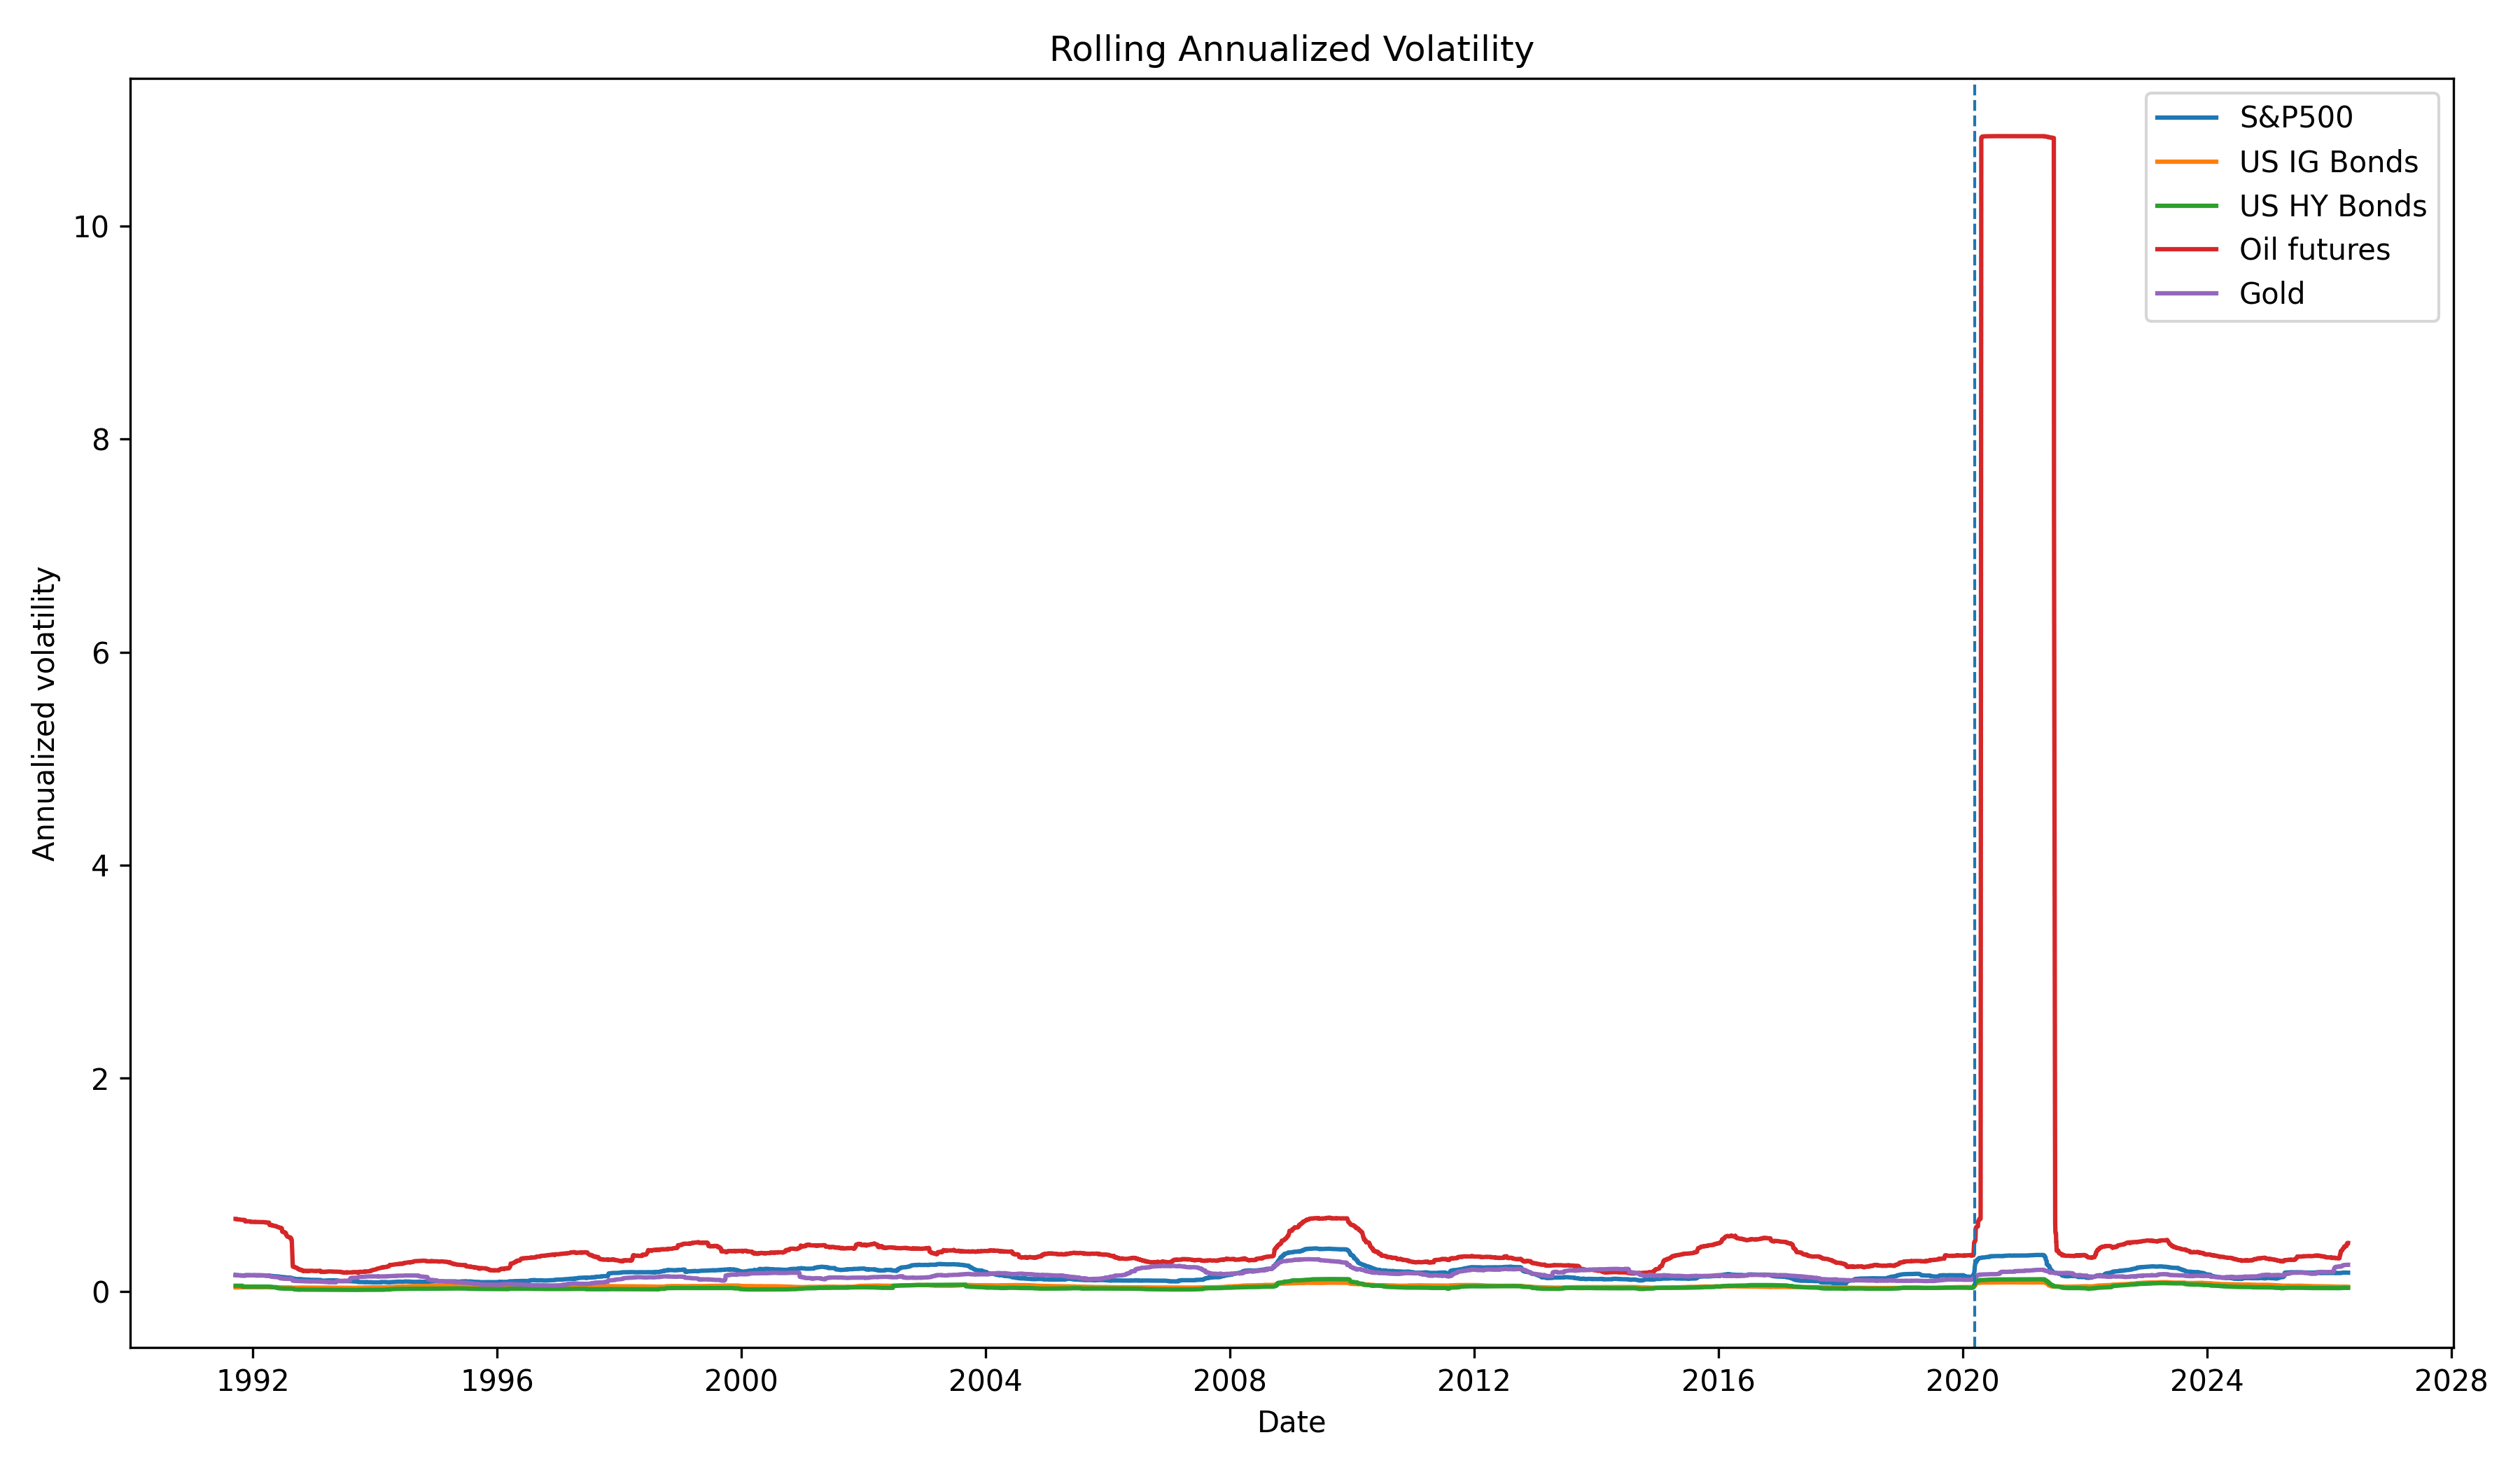

In [67]:
display(Image(filename=str(rolling_vol_img)))

### Figure: rolling average cross-asset correlation

The following figure shows the rolling average pairwise correlation across all assets. This helps assess whether cross-asset diversification changed dynamically around COVID-19.

In [68]:
plot_rolling_average_correlation(
    rolling_corr,
    output_path=FIGURE_DIR / "rolling_average_correlation.png",
)

rolling_corr_img = FIGURE_DIR / "rolling_average_correlation.png"
print("Rolling correlation figure saved to:", rolling_corr_img)

Rolling correlation figure saved to: C:\Users\Pc\Downloads\Emif-Project-2\results\figures\rolling_average_correlation.png


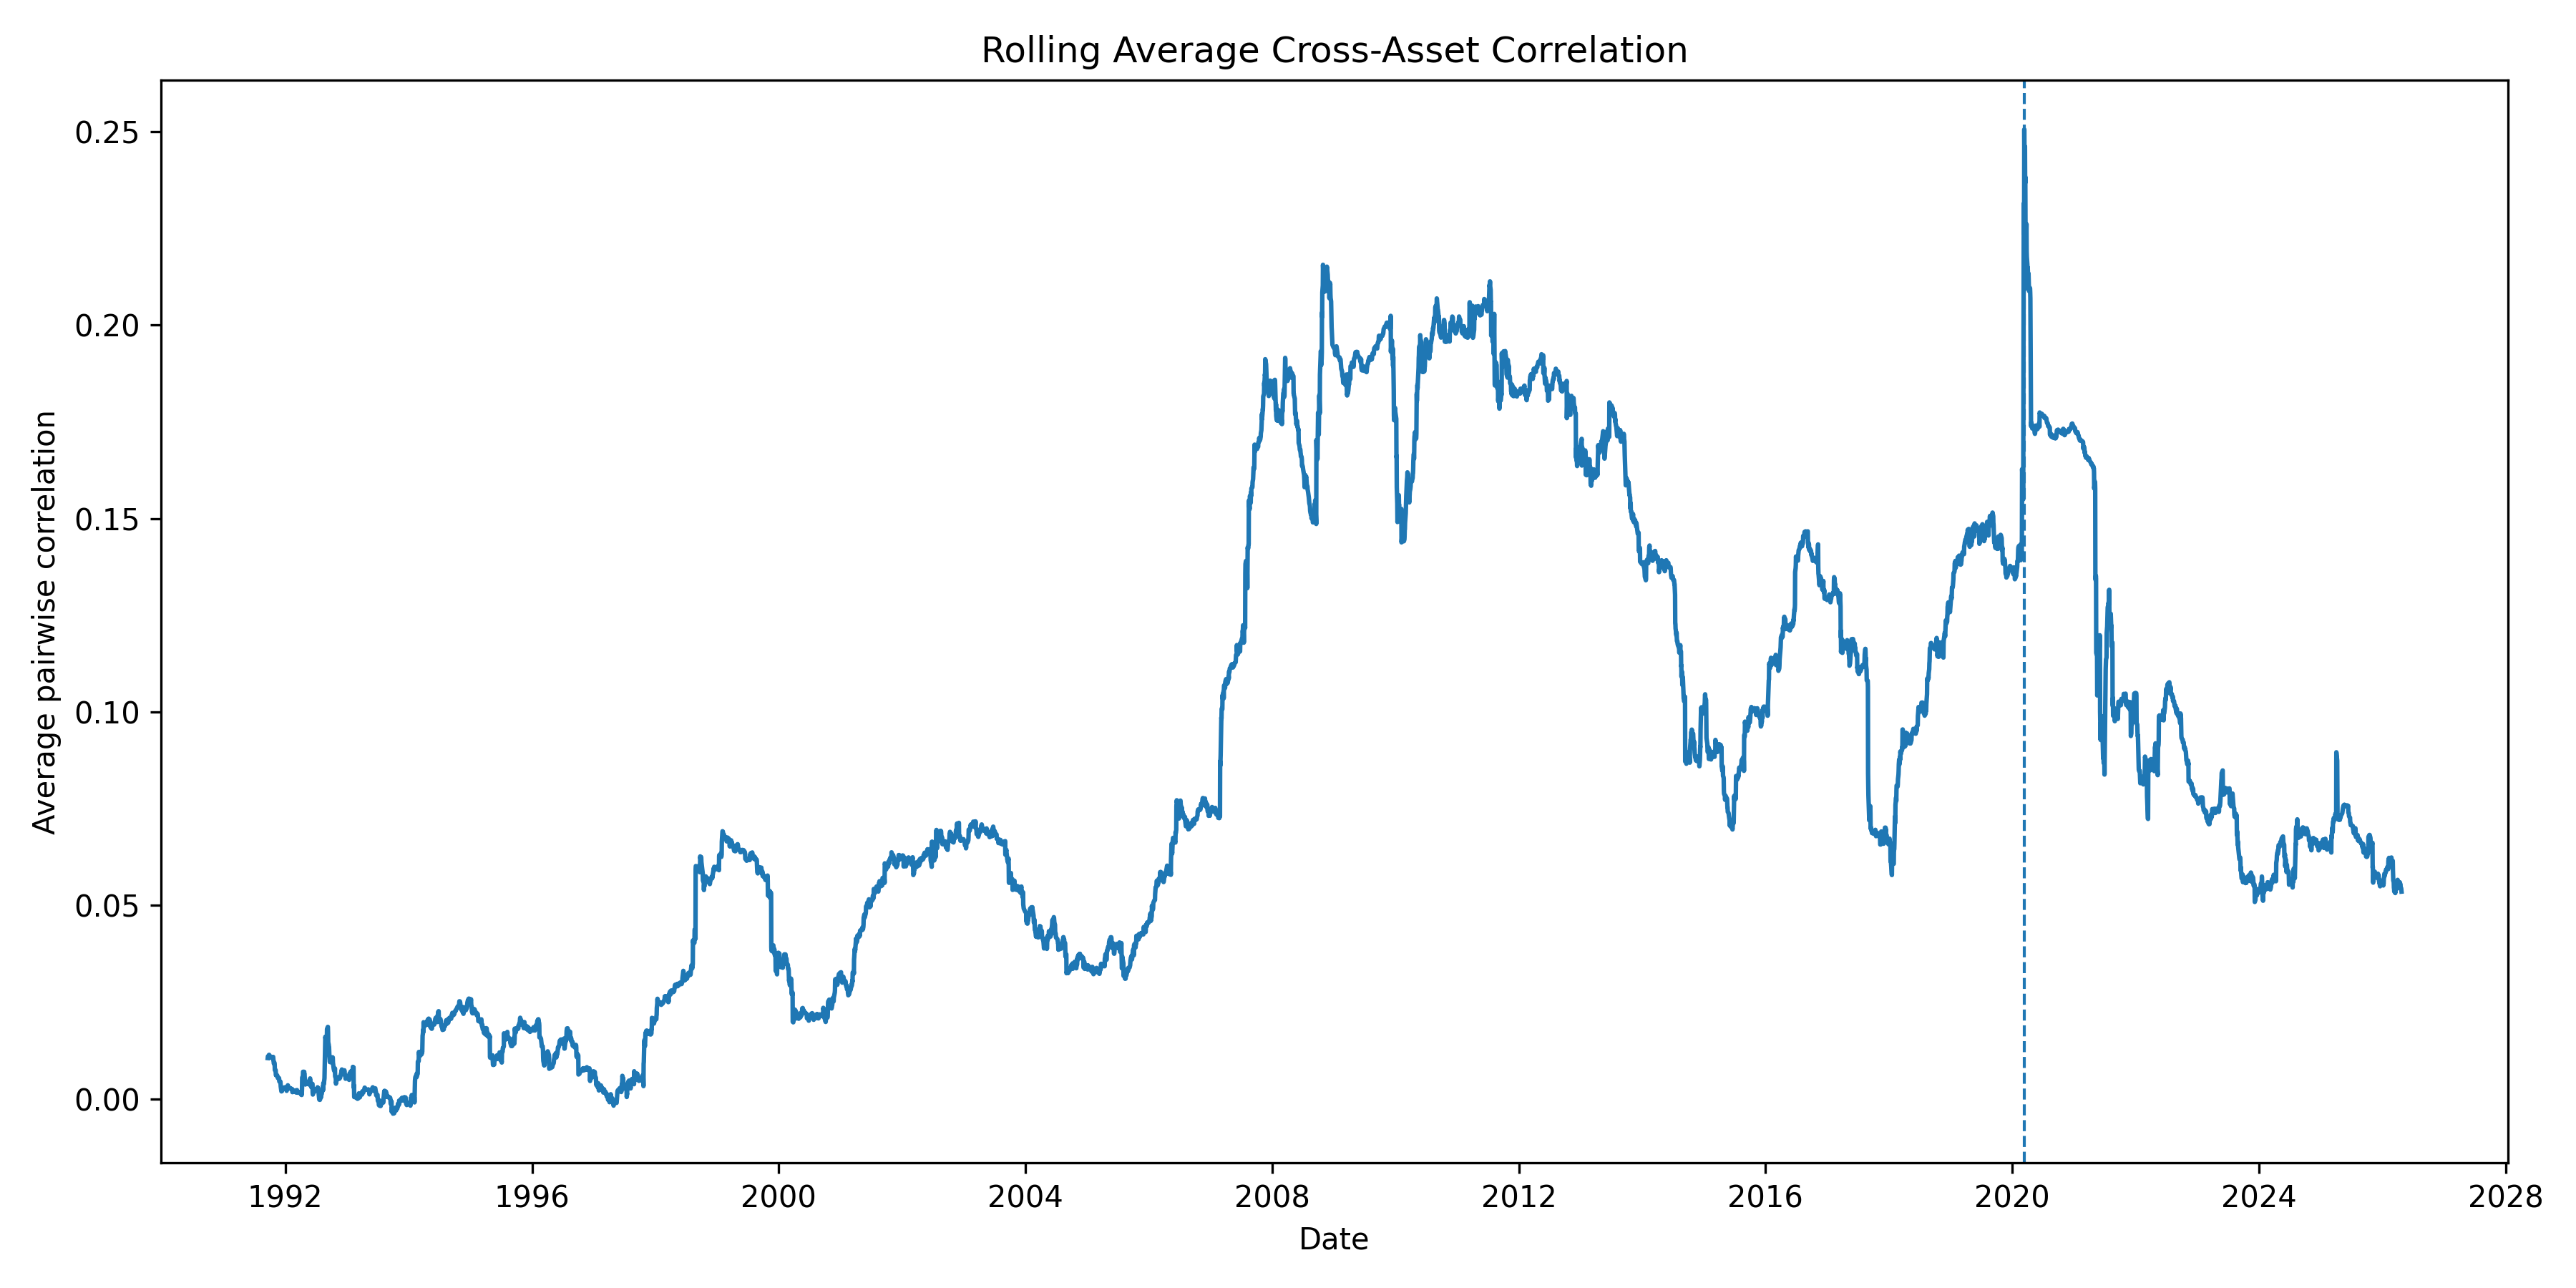

In [69]:
display(Image(filename=str(rolling_corr_img)))

### Interpretation

The rolling volatility figure shows that COVID-19 coincided with a sharp increase in risk for several assets, especially oil, equities and credit-related instruments. This confirms that the pandemic period was associated with a clear risk-regime shock.

The rolling average correlation figure provides a dynamic view of diversification. If the average correlation rises during stress periods, diversification becomes less effective. If it later declines, the shock may be more temporary. This helps distinguish between a short-lived crisis episode and a more persistent change in the risk structure.

Overall, the rolling evidence supports the idea that COVID-19 was a major risk-regime event. Combined with the pre/post tables, it suggests that the risk structure changed selectively rather than uniformly.

## 7. Robustness checks

The baseline analysis uses 11 March 2020 as the COVID breakpoint. This date corresponds to the point at which COVID-19 was officially characterized as a pandemic.

However, financial markets started reacting before and after that date. Therefore, we test whether the main conclusions are robust to alternative breakpoints.

We also run a robustness check excluding oil futures, because WTI oil prices became negative in April 2020 and therefore require a special transformation.

In [70]:
from src.robustness import (
    run_breakpoint_robustness,
    run_no_oil_robustness,
)

print("Robustness functions imported successfully.")

Robustness functions imported successfully.


In [71]:
breakpoints = [
    "2020-02-24",
    "2020-03-11",
    "2020-03-23",
    "2020-06-01",
]

breakpoint_robustness = run_breakpoint_robustness(
    returns_df,
    breakpoints=breakpoints,
)

breakpoint_robustness.round(4)

,Pre_obs,Post_obs,Average_vol_change,Average_corr_pre,Average_corr_post,Average_corr_change,PC1_pre,PC1_post,PC1_change,PC1_PC2_pre,PC1_PC2_post,PC1_PC2_change
Breakpoint,,,,,,,,,,,,
2020-02-24,6054,1278,1.6476,0.0986,0.0938,-0.0048,0.2550,0.2877,0.0327,0.4319,0.5097,0.0778
2020-03-11,6064,1268,1.4802,0.1022,0.0842,-0.0180,0.2581,0.2946,0.0365,0.4345,0.5032,0.0687
2020-03-23,6072,1260,1.1123,0.1056,0.0736,-0.0320,0.2579,0.2913,0.0334,0.4374,0.4957,0.0583
2020-06-01,6112,1220,0.7005,0.0934,0.0760,-0.0173,0.2547,0.2921,0.0374,0.4344,0.4888,0.0544


In [72]:
breakpoint_robustness.to_csv(TABLE_DIR / "breakpoint_robustness.csv")

print("Breakpoint robustness table saved.")

Breakpoint robustness table saved.


In [73]:
no_oil_results = run_no_oil_robustness(
    returns_df,
    breakpoint="2020-03-11",
)

print(no_oil_results.keys())

dict_keys(['risk_comparison_no_oil', 'correlation_summary_no_oil', 'correlation_difference_no_oil', 'pca_comparison_no_oil', 'pca_loadings_pre_no_oil', 'pca_loadings_post_no_oil'])


In [74]:
no_oil_pca = no_oil_results["pca_comparison_no_oil"]
no_oil_corr = no_oil_results["correlation_summary_no_oil"]
no_oil_risk = no_oil_results["risk_comparison_no_oil"]

print("No-oil correlation summary:")
display(no_oil_corr.round(4))

print("No-oil PCA comparison:")
display(no_oil_pca.head(5).round(4))

print("No-oil risk comparison:")
display(no_oil_risk.round(4))

No-oil correlation summary:


,Average_correlation_pre,Average_correlation_post,Change
0,0.103,0.101,-0.002


No-oil PCA comparison:


,Explained_pre,Explained_post,Change
PC1,0.2740,0.3172,0.0432
PC2,0.1892,0.2244,0.0352
PC3,0.1462,0.1209,-0.0253
PC4,0.0735,0.0928,0.0193
PC5,0.0619,0.0579,-0.0040


No-oil risk comparison:


,Vol_ann_pre,Vol_ann_post,Vol_change,Vol_change_%,Skew_pre,Skew_post,Excess_Kurtosis_pre,Excess_Kurtosis_post,VaR_5_pre,VaR_5_post,CVaR_5_pre,CVaR_5_post
Asset,,,,,,,,,,,,
S&P500,0.1735,0.2067,0.0332,0.1914,-0.3870,-0.5226,7.8723,16.8564,-0.0172,-0.0175,-0.0267,-0.0304
Eurostoxx 50,0.2077,0.1989,-0.0088,-0.0424,-0.2508,-0.7270,4.9161,14.3781,-0.0211,-0.0172,-0.0318,-0.0292
Hang Seng,0.2442,0.2365,-0.0078,-0.0318,-0.0599,0.0952,10.2691,3.1240,-0.0237,-0.0219,-0.0365,-0.0309
MSCI EM,0.1796,0.1755,-0.0041,-0.0227,-0.5314,-0.4364,7.8412,4.5872,-0.0181,-0.0165,-0.0277,-0.0256
SMI,0.1743,0.1496,-0.0247,-0.1418,-0.4761,-0.7876,5.6934,14.8558,-0.0171,-0.0134,-0.0270,-0.0216
US T 10-year Yield,92.5748,96.2001,3.6253,0.0392,0.0330,-0.1711,2.0921,2.3154,-9.2970,-9.5320,-12.7267,-13.5702
German Gov 10-year yield,69.2791,81.9287,12.6496,0.1826,0.2047,-0.2935,2.4918,3.3579,-6.6470,-7.8615,-9.3987,-12.2206
Gold,0.1557,0.1793,0.0236,0.1518,-0.2601,-0.7031,8.6104,6.5363,-0.0149,-0.0175,-0.0235,-0.0272
EURUSD,0.0969,0.0764,-0.0205,-0.2115,-0.0188,0.1122,1.8887,1.5288,-0.0099,-0.0076,-0.0138,-0.0102


In [75]:
for name, table in no_oil_results.items():
    table.to_csv(TABLE_DIR / f"{name}.csv")

print("No-oil robustness tables saved.")

No-oil robustness tables saved.


### Interpretation

The breakpoint robustness check tests whether the main conclusion depends on choosing 11 March 2020 as the COVID split date. If the direction of the main results remains similar across alternative breakpoints, the conclusion is more credible.

The no-oil robustness check is important because oil futures experienced an exceptional dislocation in April 2020. If the main PCA and correlation conclusions remain visible after excluding oil, then the results are not driven only by the oil shock.

Overall, the robustness checks are used to confirm whether the project’s conclusion is stable: COVID-19 changed the structure of risk partially and selectively, rather than uniformly across all assets.

In [76]:
breakpoint_robustness.round(4)

,Pre_obs,Post_obs,Average_vol_change,Average_corr_pre,Average_corr_post,Average_corr_change,PC1_pre,PC1_post,PC1_change,PC1_PC2_pre,PC1_PC2_post,PC1_PC2_change
Breakpoint,,,,,,,,,,,,
2020-02-24,6054,1278,1.6476,0.0986,0.0938,-0.0048,0.2550,0.2877,0.0327,0.4319,0.5097,0.0778
2020-03-11,6064,1268,1.4802,0.1022,0.0842,-0.0180,0.2581,0.2946,0.0365,0.4345,0.5032,0.0687
2020-03-23,6072,1260,1.1123,0.1056,0.0736,-0.0320,0.2579,0.2913,0.0334,0.4374,0.4957,0.0583
2020-06-01,6112,1220,0.7005,0.0934,0.0760,-0.0173,0.2547,0.2921,0.0374,0.4344,0.4888,0.0544


## 8. Final conclusion

The empirical evidence supports a **partial change** in the structure of risk after COVID-19.

The results do not support the simple idea that all assets became riskier or that all markets became more correlated. Average cross-asset correlation did not increase after COVID, and several assets experienced lower or stable volatility.

However, the structure of risk changed in more specific and economically meaningful ways.

First, risk levels increased strongly in selected areas, especially oil, government yield changes, credit bonds, gold and the S&P500. This suggests that the COVID shock affected multiple risk channels: energy risk, rates risk, credit risk and equity risk.

Second, the correlation structure changed selectively. Credit markets became more internally correlated, government yield changes became more synchronized, and the equity-credit relationship strengthened. This implies that diversification benefits changed, especially for portfolios combining equities and credit.

Third, PCA results show that risk became more concentrated in common factors. The first two principal components explain a larger share of total standardized variance after COVID than before COVID. This result is robust across alternative COVID breakpoints and remains visible even when oil futures are excluded.

Therefore, the answer to the research question is:

**Yes, but only partially. Since COVID-19, the structure of risk in financial markets has changed selectively rather than uniformly. The main change is not a generalized rise in all correlations, but a stronger concentration of risk in common macro-financial factors, especially through credit, rates and cross-asset channels.**

In [77]:
print("Notebook completed successfully.")

print("\nMain tables saved in:")
print(TABLE_DIR)

print("\nMain figures saved in:")
print(FIGURE_DIR)

print("\nKey output files:")
print("- risk_comparison_pre_post.csv")
print("- block_correlation_summary.csv")
print("- pca_explained_variance_comparison.csv")
print("- breakpoint_robustness.csv")
print("- volatility_change_pre_post.png")
print("- block_correlation_change.png")
print("- correlation_difference_heatmap.png")
print("- pca_explained_variance_pre_post.png")
print("- rolling_volatility_selected_assets.png")
print("- rolling_average_correlation.png")

Notebook completed successfully.

Main tables saved in:
C:\Users\Pc\Downloads\Emif-Project-2\results\tables

Main figures saved in:
C:\Users\Pc\Downloads\Emif-Project-2\results\figures

Key output files:
- risk_comparison_pre_post.csv
- block_correlation_summary.csv
- pca_explained_variance_comparison.csv
- breakpoint_robustness.csv
- volatility_change_pre_post.png
- block_correlation_change.png
- correlation_difference_heatmap.png
- pca_explained_variance_pre_post.png
- rolling_volatility_selected_assets.png
- rolling_average_correlation.png
